# EXPLORATORY DATA ANALYSIS (EDA)
## Blood Cell Image Dataset — Blood Cell Classification

---

## Objective

Explore and understand the microscopic blood cell image dataset before training any model.

The EDA will allow us to:

- Understand the structure and distribution of the dataset  
- Detect potential class imbalances  
- Analyze the statistical characteristics of the images  
- Define the preprocessing strategy for CNN models  

---

## Dataset: Blood Cell Image Dataset

| Attribute | Detail |
|---|---|
| Source | Kaggle — Paul Mooney |
| Classes | 4: EOSINOPHIL, LYMPHOCYTE, MONOCYTE, NEUTROPHIL |
| Total images | ~12,500 RGB images |
| Original resolution | 320×240 px |
| Split | Train / Test already provided |
| License | CC0: Public Domain |

---

## SECTION 1: Setup and Imports

---

In [1]:
%pip install numpy matplotlib seaborn pillow
%pip install --index-url https://download.pytorch.org/whl/cu132 torch torchvision --force-reinstall

  Using cached numpy-2.4.5-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached numpy-2.4.5-cp314-cp314-win_amd64.whl (12.5 MB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached pillow-12.2.0-cp314-cp314

In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import os                          # Path and directory management
import random                      # Random image selection
import numpy as np                 # Numerical operations
import matplotlib.pyplot as plt    # Plot visualization
import matplotlib.gridspec as gridspec  # Advanced subplot layout
import seaborn as sns              # Statistical visualization

from PIL import Image              # Image reading
from collections import Counter    # Element counting
from pathlib import Path           # Modern path management

import torch                       # Main PyTorch framework
import torchvision.transforms as transforms  # Image transformations
from torchvision.datasets import ImageFolder  # Automatic folder-based loading
from torch.utils.data import DataLoader       # Batch iterator

# ==============================
# 2. SET REPRODUCIBILITY SEED
# ==============================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✓ Libraries imported successfully")
print(f"   PyTorch version: {torch.__version__}")
print(f"   CUDA build: {torch.version.cuda}")
print(f"   CUDA available: {torch.cuda.is_available()}")
print(f"   Seed set: {SEED}")

✓ Libraries imported successfully
   PyTorch version: 2.12.0+cu132
   CUDA build: 13.2
   CUDA available: True
   Seed set: 42


## SECTION 2: Dataset Structure

---

The dataset was downloaded using `data/download_data.sh` and the following folder structure is expected:

```
data/
└── blood-cells/
    ├── dataset2-master/
    │   └── images/
    │       ├── TRAIN/
    │       │   ├── EOSINOPHIL/
    │       │   ├── LYMPHOCYTE/
    │       │   ├── MONOCYTE/
    │       │   └── NEUTROPHIL/
    │       └── TEST/
    │           ├── EOSINOPHIL/
    │           ├── LYMPHOCYTE/
    │           ├── MONOCYTE/
    │           └── NEUTROPHIL/
```

---

In [3]:
# ==============================
# DEFINE DATASET PATHS
# ==============================

# Base path for the dataset (adjusted to the actual local structure)
DATA_ROOT = Path("../data/raw/dataset2-master/dataset2-master/images")

TRAIN_DIR = DATA_ROOT / "TRAIN"
TEST_DIR  = DATA_ROOT / "TEST"

# Verify that paths exist
assert TRAIN_DIR.exists(), f"TRAIN folder not found at: {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"TEST folder not found at: {TEST_DIR}"

# Dataset classes
CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])

print("✓ Paths verified successfully")
print(f"   Train: {TRAIN_DIR}")
print(f"   Test:  {TEST_DIR}")
print(f"   Classes found ({len(CLASSES)}): {CLASSES}")

✓ Paths verified successfully
   Train: ..\data\raw\dataset2-master\dataset2-master\images\TRAIN
   Test:  ..\data\raw\dataset2-master\dataset2-master\images\TEST
   Classes found (4): ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


In [4]:
# ==============================
# COUNT IMAGES BY CLASS AND SPLIT
# ==============================

def count_images(directory, classes):
    """Counts the number of images per class in a given directory."""
    count = {}
    for cls in classes:
        class_path = directory / cls
        # Count only image files (.jpg, .jpeg, .png)
        n = len([f for f in class_path.iterdir()
                 if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
        count[cls] = n
    return count

# Count images in each split
count_train = count_images(TRAIN_DIR, CLASSES)
count_test  = count_images(TEST_DIR, CLASSES)

total_train = sum(count_train.values())
total_test  = sum(count_test.values())
total_total = total_train + total_test

# Display summary
print("=" * 55)
print(f"{'CLASS':<15} {'TRAIN':>10} {'TEST':>10} {'TOTAL':>10}")
print("=" * 55)
for cls in CLASSES:
    total_cls = count_train[cls] + count_test[cls]
    print(f"{cls:<15} {count_train[cls]:>10} {count_test[cls]:>10} {total_cls:>10}")
print("-" * 55)
print(f"{'TOTAL':<15} {total_train:>10} {total_test:>10} {total_total:>10}")
print("=" * 55)

CLASS                TRAIN       TEST      TOTAL
EOSINOPHIL            2497        623       3120
LYMPHOCYTE            2483        620       3103
MONOCYTE              2478        620       3098
NEUTROPHIL            2499        624       3123
-------------------------------------------------------
TOTAL                 9957       2487      12444


## SECTION 3: Class Distribution

---

A **balanced dataset** has approximately the same number of samples per class.
Class imbalance can cause the model to always predict the majority class,
achieving high accuracy but low real utility in medical classification.

---

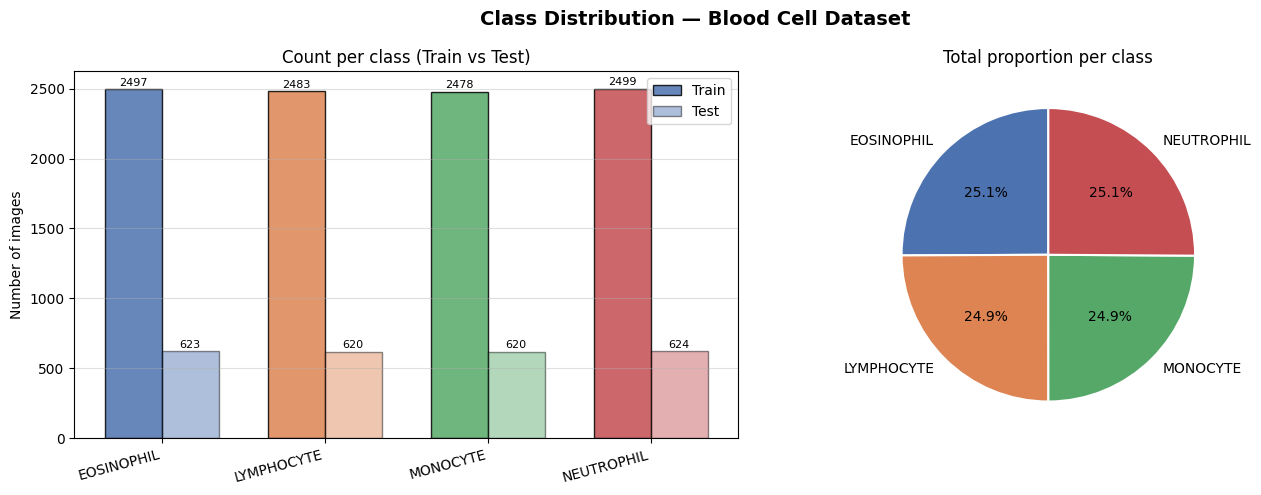

✓ Figure saved to results/figures/


In [5]:
# ==============================
# VISUALIZE CLASS DISTRIBUTION
# ==============================

# Colors per class
COLORES = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Distribution — Blood Cell Dataset", fontsize=14, fontweight="bold")

# --- Subplot 1: Bars by split ---
x = np.arange(len(CLASSES))
width = 0.35

bars_train = axes[0].bar(x - width/2,
                         [count_train[c] for c in CLASSES],
                         width, label="Train", color=COLORES, alpha=0.85, edgecolor="black")
bars_test  = axes[0].bar(x + width/2,
                         [count_test[c] for c in CLASSES],
                         width, label="Test",  color=COLORES, alpha=0.45, edgecolor="black")

axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASSES, rotation=15, ha="right")
axes[0].set_ylabel("Number of images")
axes[0].set_title("Count per class (Train vs Test)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.4)

# Add labels above bars
for bar in bars_train:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)
for bar in bars_test:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)

# --- Subplot 2: Total pie chart ---
totals = [count_train[c] + count_test[c] for c in CLASSES]
axes[1].pie(totals,
            labels=CLASSES,
            colors=COLORES,
            autopct="%1.1f%%",
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Total proportion per class")

plt.tight_layout()
plt.savefig("../results/figures/eda_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved to results/figures/")

### Analysis Observations

- The dataset is balanced across classes, with approximadely each one taking 25%
- The Train/Test ratio is consistent across classes with an 80/20 split

---

## SECTION 4: Sample Image Visualization

---

Before processing images with a CNN, it is important to view them directly
to understand their visual content, variability, and potential artifacts.

---

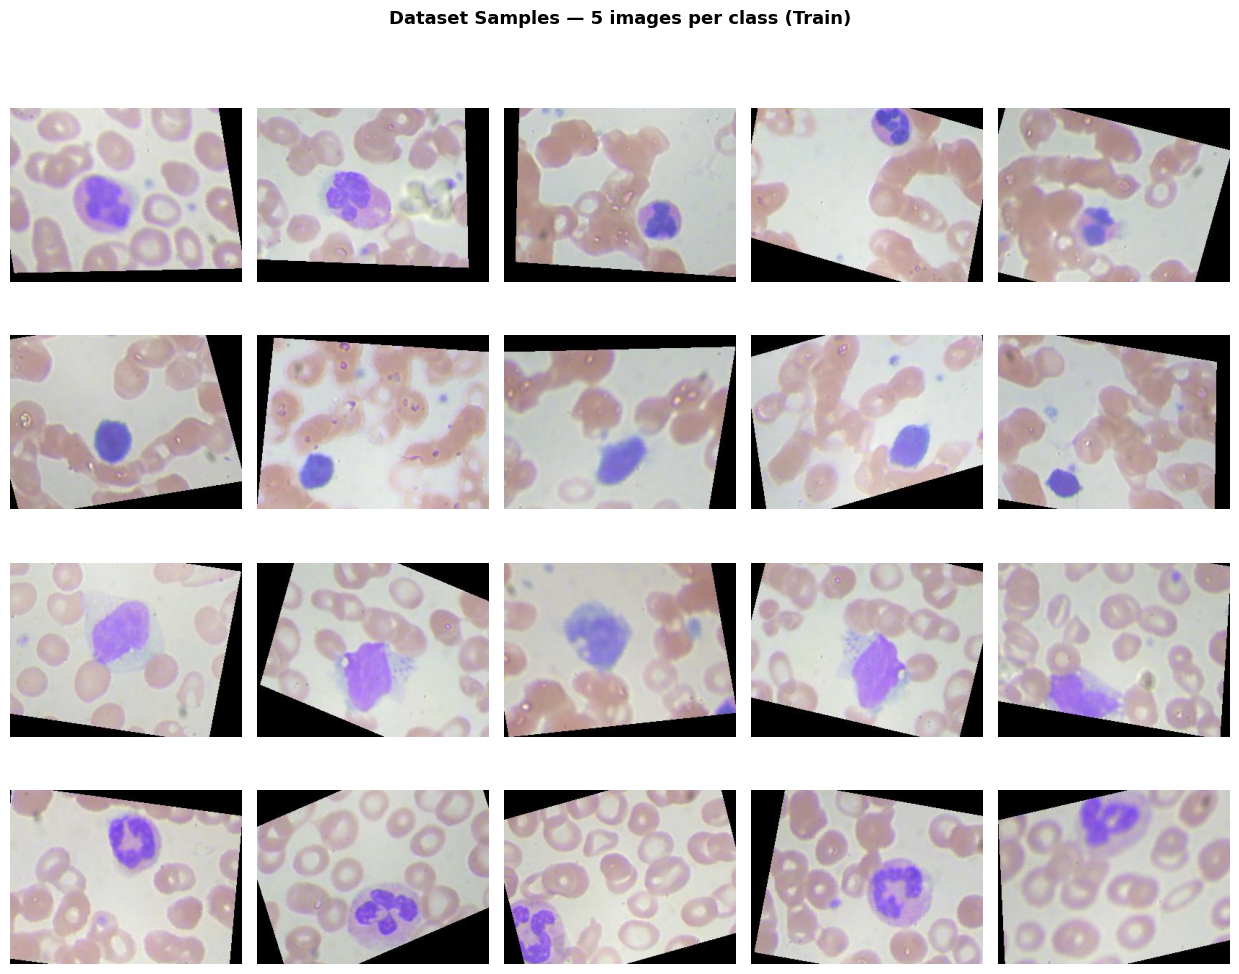

✓ Figure saved to results/figures/


In [6]:
# ==============================
# SHOW SAMPLE IMAGES PER CLASS
# ==============================

N_SAMPLES = 5  # Number of images to display per class

fig, axes = plt.subplots(len(CLASSES), N_SAMPLES,
                         figsize=(N_SAMPLES * 2.5, len(CLASSES) * 2.5))
fig.suptitle("Dataset Samples — 5 images per class (Train)",
             fontsize=13, fontweight="bold", y=1.01)

for i, cls in enumerate(CLASSES):
    class_path = TRAIN_DIR / cls

    # Randomly select N_SAMPLES images from the class
    files = [f for f in class_path.iterdir()
                if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    samples = random.sample(files, N_SAMPLES)

    for j, file in enumerate(samples):
        img = Image.open(file).convert("RGB")
        axes[i][j].imshow(img)
        axes[i][j].axis("off")

        # Class label only on the first column
        if j == 0:
            axes[i][j].set_ylabel(cls, fontsize=10, fontweight="bold",
                                  rotation=0, labelpad=60, va="center")

plt.tight_layout()
plt.savefig("../results/figures/eda_samples_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved to results/figures/")

## SECTION 5: Image Dimensions and Resolution Analysis

---

CNN models require all images to have the **same input size**.
It is important to verify whether all images in the dataset have uniform resolution
or if there is variability that needs to be handled during preprocessing.

---

In [7]:
# ==============================
# ANALYZE IMAGE DIMENSIONS AND CHANNELS
# ==============================

widths, heights, channels = [], [], []

# Iterate over a representative sample from the training set
for cls in CLASSES:
    class_path = TRAIN_DIR / cls
    files = list(class_path.iterdir())[:50]  # Sample of 50 per class
    for file in files:
        if file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            img = Image.open(file)
            w, h = img.size
            widths.append(w)
            heights.append(h)
            channels.append(len(img.getbands()))

widths   = np.array(widths)
heights  = np.array(heights)
channels = np.array(channels)

# Statistical summary
print("IMAGE DIMENSIONS (sample of 50 per class)")
print("=" * 45)
print(f"  Width  — min: {widths.min()}, max: {widths.max()}, mean: {widths.mean():.1f}")
print(f"  Height — min: {heights.min()}, max: {heights.max()}, mean: {heights.mean():.1f}")
print(f"  Channels — unique: {np.unique(channels)}")
print(f"  All RGB? {'Yes' if (channels == 3).all() else 'No — review'}")
print("=" * 45)

IMAGE DIMENSIONS (sample of 50 per class)
  Width  — min: 320, max: 320, mean: 320.0
  Height — min: 240, max: 240, mean: 240.0
  Channels — unique: [3]
  All RGB? Yes


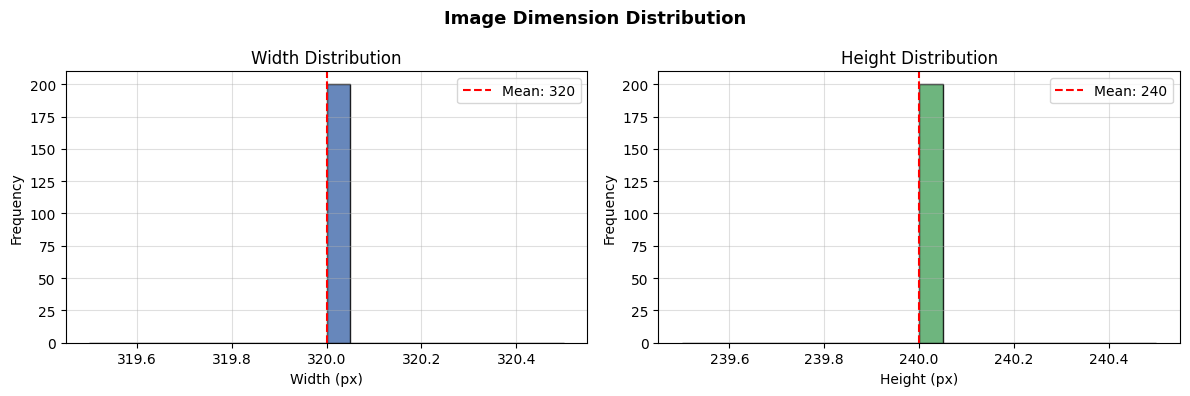

✓ Figure saved to results/figures/


In [8]:
# ==============================
# DIMENSION DISTRIBUTION HISTOGRAMS
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Image Dimension Distribution", fontsize=13, fontweight="bold")

# Width histogram
axes[0].hist(widths, bins=20, color="#4C72B0", edgecolor="black", alpha=0.85)
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Width Distribution")
axes[0].axvline(widths.mean(), color="red", linestyle="--", label=f"Mean: {widths.mean():.0f}")
axes[0].legend()
axes[0].grid(alpha=0.4)

# Height histogram
axes[1].hist(heights, bins=20, color="#55A868", edgecolor="black", alpha=0.85)
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Height Distribution")
axes[1].axvline(heights.mean(), color="red", linestyle="--", label=f"Mean: {heights.mean():.0f}")
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig("../results/figures/eda_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved to results/figures/")

## SECTION 6: Pixel Statistics Analysis

---

To correctly normalize images before training the CNN,
we need to compute the **mean** $\mu$ and **standard deviation** $\sigma$ for each color channel (R, G, B).

The normalization we will apply is:

$$
x_{norm} = \frac{x - \mu}{\sigma}
$$

Where $x \in [0, 1]$ after dividing pixel values by 255.

---

In [9]:
# ==============================
# CALCULATE MEAN AND STD FOR NORMALIZATION
# ==============================

# Basic transform: resize and convert to tensor
transform_stats = transforms.Compose([
    transforms.Resize((64, 64)),   # Resize to the model's target size
    transforms.ToTensor()          # Convert to tensor [0,1] with shape (C, H, W)
])

# Load the training set with ImageFolder
dataset_train = ImageFolder(root=str(TRAIN_DIR), transform=transform_stats)
loader_stats  = DataLoader(dataset_train, batch_size=128, shuffle=False, num_workers=0)

# Per-channel accumulators
sum_    = torch.zeros(3)  # Sum of values per channel R, G, B
sum_sq  = torch.zeros(3)  # Sum of squared values
n_pixels  = 0             # Total pixels processed

print("Computing training dataset statistics...")

for images, _ in loader_stats:
    # images shape: (batch, 3, 64, 64)
    b, c, h, w = images.shape
    n_pixels += b * h * w                          # Accumulate total pixels
    sum_    += images.sum(dim=[0, 2, 3])            # Sum per channel
    sum_sq  += (images ** 2).sum(dim=[0, 2, 3])     # Sum of squares per channel

# Compute mean and standard deviation
mean  = sum_ / n_pixels
std   = torch.sqrt(sum_sq / n_pixels - mean ** 2)

print("\nTRAINING DATASET STATISTICS (64×64 px)")
print("=" * 50)
print(f"  Mean   — R: {mean[0]:.4f}  G: {mean[1]:.4f}  B: {mean[2]:.4f}")
print(f"  Std    — R: {std[0]:.4f}  G: {std[1]:.4f}  B: {std[2]:.4f}")
print("=" * 50)
print("\nThese values will be used in transforms.Normalize() for all models.")

Computing training dataset statistics...

TRAINING DATASET STATISTICS (64×64 px)
  Mean   — R: 0.6788  G: 0.6415  B: 0.6606
  Std    — R: 0.2566  G: 0.2555  B: 0.2535

These values will be used in transforms.Normalize() for all models.


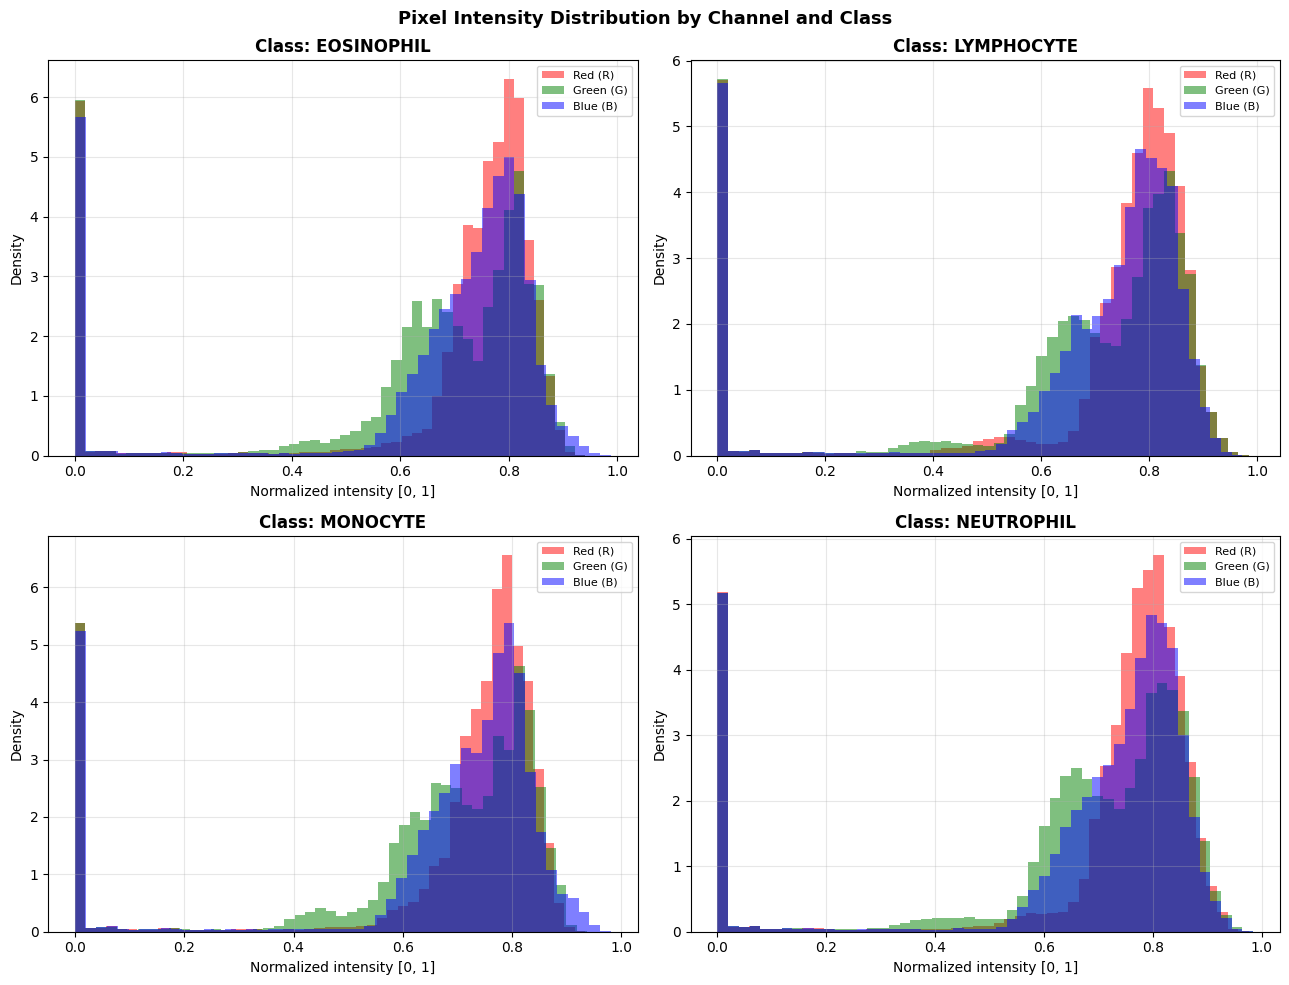

✓ Figure saved to results/figures/


In [10]:
# ==============================
# PIXEL INTENSITY DISTRIBUTION BY CHANNEL AND CLASS
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Pixel Intensity Distribution by Channel and Class",
             fontsize=13, fontweight="bold")

CHANNEL_NAMES = ["Red (R)", "Green (G)", "Blue (B)"]
CHANNEL_COLORS = ["red", "green", "blue"]

for idx, cls in enumerate(CLASSES):
    ax = axes[idx // 2][idx % 2]
    class_path = TRAIN_DIR / cls

    # Take a sample of 30 images per class
    files = [f for f in class_path.iterdir()
                if f.suffix.lower() in [".jpg", ".jpeg", ".png"]][:30]

    # Accumulate pixels per channel
    pixels = {"R": [], "G": [], "B": []}
    for file in files:
        img = np.array(Image.open(file).convert("RGB").resize((64, 64))) / 255.0
        pixels["R"].extend(img[:, :, 0].flatten())
        pixels["G"].extend(img[:, :, 1].flatten())
        pixels["B"].extend(img[:, :, 2].flatten())

    # Plot histogram per channel
    for channel, name, color in zip(["R", "G", "B"], CHANNEL_NAMES, CHANNEL_COLORS):
        ax.hist(pixels[channel], bins=50, alpha=0.5, color=color,
                label=name, density=True)

    ax.set_title(f"Class: {cls}", fontweight="bold")
    ax.set_xlabel("Normalized intensity [0, 1]")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/eda_pixel_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved to results/figures/")

## SECTION 7: Resizing Effect

---

The assignment requires resizing images to **64×64 px** for LeNet-5 and VGG-11.
We visualize the effect of this resizing to ensure that
the relevant diagnostic features are preserved.

---

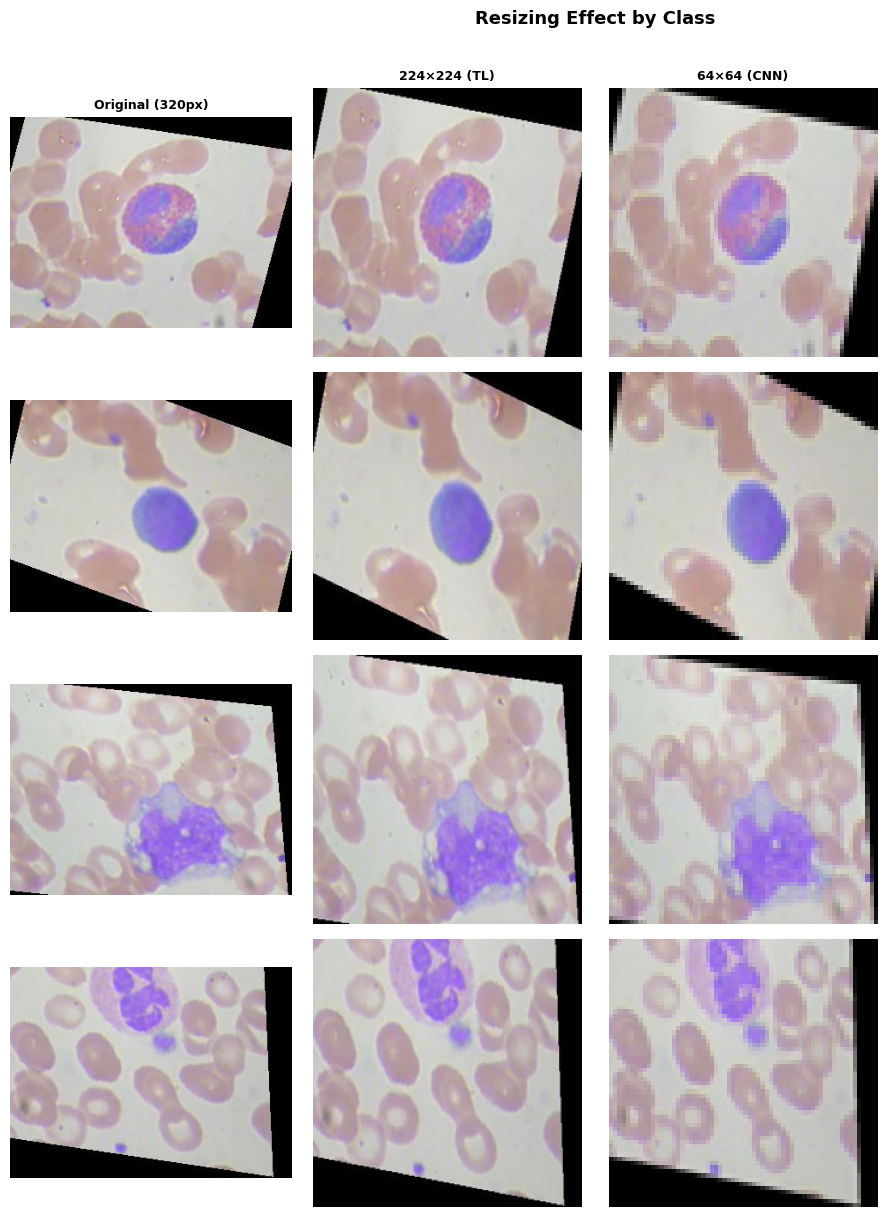

✓ Figure saved to results/figures/


In [11]:
# ==============================
# COMPARE RESIZING EFFECTS ON SAMPLE IMAGES
# ==============================

SIZES = [320, 224, 64]  # Original, Transfer Learning, LeNet/VGG

fig, axes = plt.subplots(len(CLASSES), len(SIZES) + 1,
                         figsize=((len(SIZES) + 1) * 3, len(CLASSES) * 3))
fig.suptitle("Resizing Effect by Class",
             fontsize=13, fontweight="bold", y=1.01)

# Column labels
col_labels = ["Original (320px)", "224×224 (TL)", "64×64 (CNN)"]

for i, cls in enumerate(CLASSES):
    class_path = TRAIN_DIR / cls
    file = next(f for f in class_path.iterdir()
                   if f.suffix.lower() in [".jpg", ".jpeg", ".png"])
    img_original = Image.open(file).convert("RGB")

    images_to_show = [
        img_original.resize((320, 240)),
        img_original.resize((224, 224)),
        img_original.resize((64, 64)),
    ]

    for j, (img, label) in enumerate(zip(images_to_show, col_labels)):
        axes[i][j].imshow(img)
        axes[i][j].axis("off")
        if i == 0:
            axes[i][j].set_title(label, fontsize=9, fontweight="bold")
        if j == 0:
            axes[i][j].set_ylabel(cls, fontsize=9, fontweight="bold",
                                  rotation=0, labelpad=70, va="center")

    # Last column: display pixel array of the 64×64 tensor
    arr = np.array(img_original.resize((64, 64))) / 255.0
    axes[i][-1].imshow(arr)
    axes[i][-1].axis("off")
    if i == 0:
        axes[i][-1].set_title("Tensor [0,1]", fontsize=9, fontweight="bold")

# Hide unused columns
for ax in axes[:, -1]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/eda_resizing.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved to results/figures/")

### Analysis Observations

- The relevant diagnostic features of the cells are preserved at 64×64 px for coarse and class-level features (overall cell shape, relative nucleus size, and major color/contrast cues). However, fine texture, small granules, chromatin detail, and very small boundaries become blurred or lost at 64×64, so some subtle diagnostic cues may be degraded.
- Resizing to 64×64 reduces sharpness and fine texture, smooths edges, blends nearby colors, and can introduce aliasing or pixelation; 224×224 preserves far more detail and spatial context, while the original (320×240) retains the richest texture and background information.
- 224×224 is preferred for Transfer Learning with ResNet/VGG pretrained on ImageNet because the networks' learned receptive fields and feature scales, preserves finer image detail that pretrained filters expect, and lets you reuse pretrained weights and ImageNet normalization (mean/std) directly for better transfer performance.

---

## SECTION 8: Preprocessing Proposal

---

Based on the previous analysis, we define the transformations to be applied
in the training notebooks. Two pipelines are defined:

| Pipeline | Use | Size |
|---|---|---|
| `transform_train` | LeNet-5 and VGG-11 (Tasks 1-2) | 64×64 |
| `transform_tl` | Transfer Learning ResNet-18 (Task 3) | 224×224 |

---

In [12]:
# ==============================
# PREPROCESSING PIPELINES
# ==============================

# Values computed in Section 6 (replace with results obtained above)
MEAN = mean.tolist()  # [R, G, B]
STD  = std.tolist()   # [R, G, B]

# --- Pipeline for LeNet-5 and VGG-11 (Tasks 1 and 2) ---
transform_cnn_train = transforms.Compose([
    transforms.Resize((64, 64)),            # Resize to the target size
    transforms.RandomHorizontalFlip(),      # Augmentation: horizontal flip
    transforms.RandomRotation(10),          # Augmentation: rotation ±10°
    transforms.ColorJitter(brightness=0.2,  # Augmentation: color variation
                           contrast=0.2),
    transforms.ToTensor(),                  # Convert to tensor [C, H, W] in [0,1]
    transforms.Normalize(mean=MEAN, std=STD)  # Normalize per channel
])

transform_cnn_test = transforms.Compose([
    transforms.Resize((64, 64)),            # Resize only (no augmentation)
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# --- Pipeline for Transfer Learning (Task 3) ---
# ImageNet uses 224×224 and its own normalization values
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_tl_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

transform_tl_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("✓ Preprocessing pipelines defined")
print()
print("transform_cnn_train  → Tasks 1 and 2 (LeNet / VGG-11) — 64×64")
print("transform_cnn_test   → Test evaluation — 64×64")
print("transform_tl_train   → Task 3 (Transfer Learning) — 224×224")
print("transform_tl_test    → Transfer Learning evaluation — 224×224")

✓ Preprocessing pipelines defined

transform_cnn_train  → Tasks 1 and 2 (LeNet / VGG-11) — 64×64
transform_cnn_test   → Test evaluation — 64×64
transform_tl_train   → Task 3 (Transfer Learning) — 224×224
transform_tl_test    → Transfer Learning evaluation — 224×224


In [13]:
# ==============================
# VERIFY DATALOADERS WITH FINAL PIPELINES
# ==============================

# Load datasets with the final pipelines
dataset_train_final = ImageFolder(root=str(TRAIN_DIR), transform=transform_cnn_train)
dataset_test_final  = ImageFolder(root=str(TEST_DIR),  transform=transform_cnn_test)

loader_train = DataLoader(dataset_train_final, batch_size=32, shuffle=True,  num_workers=0)
loader_test  = DataLoader(dataset_test_final,  batch_size=32, shuffle=False, num_workers=0)

# Take a sample batch and verify dimensions
images_batch, labels_batch = next(iter(loader_train))

print("✓ DataLoaders created successfully")
print()
print(f"  Train samples     : {len(dataset_train_final)}")
print(f"  Test samples      : {len(dataset_test_final)}")
print(f"  Mapped classes    : {dataset_train_final.class_to_idx}")
print()
print(f"  Batch shape       : {images_batch.shape}  (batch=32, C=3, H=64, W=64)")
print(f"  Tensor dtype      : {images_batch.dtype}")
print(f"  Tensor min value  : {images_batch.min():.4f}")
print(f"  Tensor max value  : {images_batch.max():.4f}")

✓ DataLoaders created successfully

  Train samples     : 9957
  Test samples      : 2487
  Mapped classes    : {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}

  Batch shape       : torch.Size([32, 3, 64, 64])  (batch=32, C=3, H=64, W=64)
  Tensor dtype      : torch.float32
  Tensor min value  : -2.6455
  Tensor max value  : 1.4032


## SECTION 9: EDA Summary

---

### Main Findings

| Aspect | Observation |
|---|---|
| Total images | ~12,500 RGB images |
| Class balance | Fill in with results from Section 3 |
| Original resolution | Uniform 320×240 px |
| Target resolution (CNN) | 64×64 px |
| Target resolution (TL) | 224×224 px |
| CNN Normalization | Computed from the training set |
| TL Normalization | Standard ImageNet values |
| Data Augmentation | Flip, rotation, color jitter |

### Design Decisions Made

1. Images are resized to **64×64** for LeNet-5 and simplified VGG-11  
2. For Transfer Learning, **224×224** is used with ImageNet normalization  
3. Data Augmentation is applied **only on Train** (never on Test/Val)  
4. The global seed **42** ensures reproducibility across all notebooks  

---

**Next step →** `02_lenet_vgg.ipynb`: Implementation and comparison of LeNet-5 and VGG-11 with and without Batch Normalization.